<font size="3">**Tarea 1 2026**</font>

<u> *Instrucciones* </u>

Su notebook con las respuestas a la tarea se deben entregar a mas tardar el dia 20/04/26 hasta las 23:59, subiendolo al repositorio en la carpeta tareas/2026 mediante un *pull request* desde su fork. 

Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. La data a utilizar es **student_productivity.csv**.

Las variables tienen la siguiente descripcion:

- student_id: Identificador único del estudiante.
- age: Edad del estudiante en años.
- gender: Género informado.
- academic_level: Nivel académico actual del estudiante.
- study_hours: Horas totales de estudio diario (incluye estudio en horario de clases y autoestudio).
- self_study_hours: Horas de estudio autónomo fuera de clases.
- online_classes_hours: Horas de clases online (Zoom, Teams, etc).
- social_media_hours: Horas diarias en redes sociales.
- gaming_hours: Horas diarias de videojuegos.
- screen_time_hours: Tiempo total frente a pantallas en horas.
- sleep_hours: Horas de sueño diarias.
- exercise_minutes: Minutos de ejercicio físico diario.
- caffeine_intake_mg: Miligramos de cafeína consumidos de forma diaria.
- part_time_job: Indica si es que el estudiante tiene un trabajo de medio tiempo o no.
- upcoming_deadline: Indica si es que el estudiante tiene alguna entrega o examen próximamente.
- internet_quality: Calidad de la conexión a internet disponible para estudiar.
- drug_use: Indicador de consumo de sustancias recreativas.
- mental_health_score: Puntuación de salud mental del estudiante autoreportada.
- focus_index: Indice que nos indica el nivel de concentración del estudiante.
- burnout_level: Nivel de agotamiento del estudiante.
- productivity_score: Nivel de productividad del estudiante.
- exam_score: Puntuación en el examen final (1.0 indica un estudiante que no rindio el examen).

<u> Preguntas (todas tienen el mismo puntaje): </u> 

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.

Cargamos las librerias necesarias

In [1]:
import pandas as pd
from sklearn.impute import KNNImputer
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import missingno as msno

Luego procedemos a limpiar los datos

<Axes: >

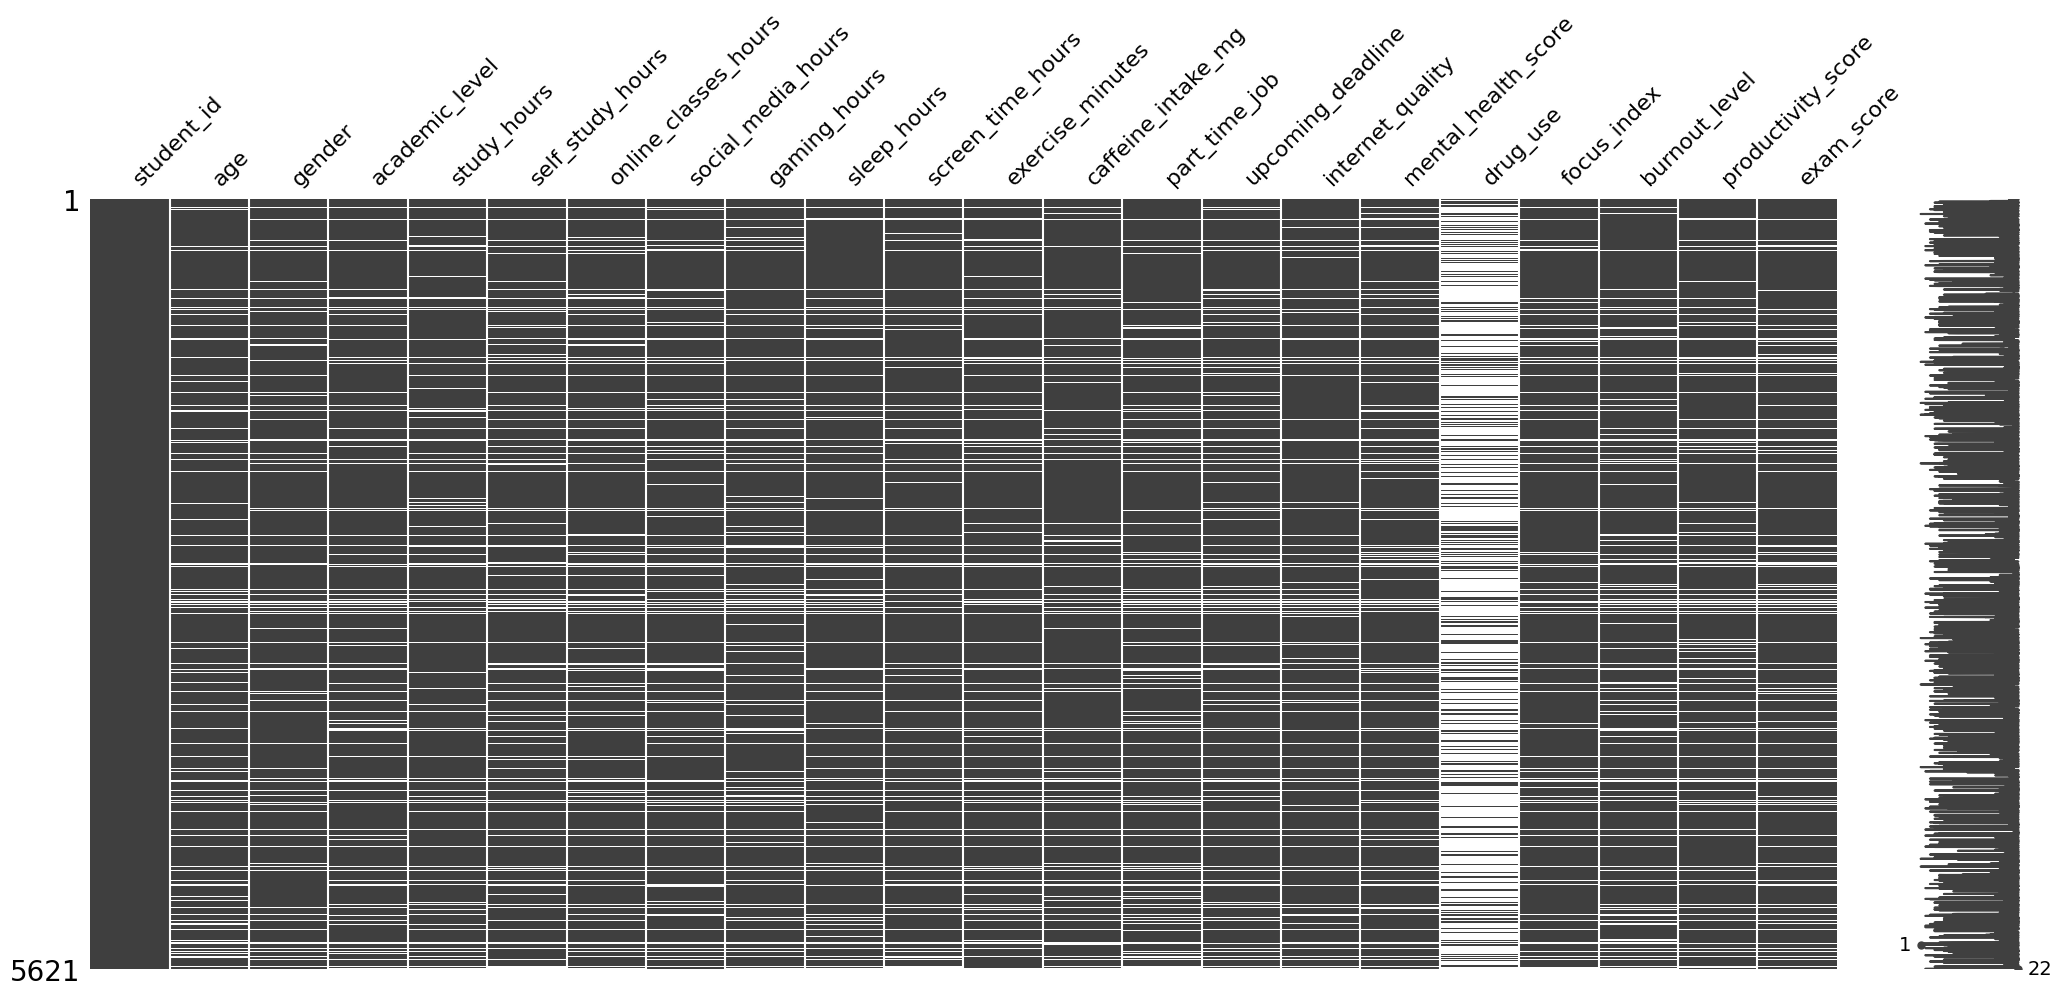

In [ ]:
df = pd.read_csv('student_productivity.csv')
msno.matrix(df)

Notamos una alto porcentaje de valores nulos en la columna "drug_use" por lo que procederemos a eliminarla

In [3]:
df = df.drop(columns="drug_use")
#df = df[df['exam_score'] != 1.0]
df = df.dropna(subset=['exam_score'])

Aplicamos limpieza general a algunas columnas


In [4]:
df['academic_level'] = df['academic_level'].str.strip()
df['part_time_job'] = df['part_time_job'].str.strip().str.lower() 
academic_mapping = {'High School': 1.0, 'Undergraduate': 2.0, 'Postgraduate': 3.0}
df['academic_level'] = df['academic_level'].map(academic_mapping)
job_mapping = {'no': 0, 'yes': 1.0, 'Yes' : 1.0, 'No' : 0}
df['part_time_job'] = df['part_time_job'].map(job_mapping)
calidad_map = {'Poor': 1.0, 'Average': 2.0, 'Good': 3.0}
df['internet_quality'] = df['internet_quality'].map(calidad_map)
df['exercise_minutes'] = df['exercise_minutes'].astype(str).str.replace(' min', '', regex=False)
df['exercise_minutes'] = df['exercise_minutes'].str.strip()
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')

Ahora aplicamos imputacion

In [5]:

columnas_knn = ['age', 'academic_level', 'part_time_job', 'study_hours', 'sleep_hours']


imputer = KNNImputer(n_neighbors=5, weights='distance')


df_imputed = pd.DataFrame(imputer.fit_transform(df[columnas_knn]), columns=columnas_knn, index=df.index)

# 6. Actualizar el DataFrame original (AQUÍ ESTÁ LA MAGIA)

# Para las variables que deben ser números enteros (discretas o categóricas mapeadas):
# Usamos .round() para acercarlo a la categoría/entero más próximo y .astype(int) para quitar los decimales.
df['age'] = df_imputed['age'].round().astype(int)
df['academic_level'] = df_imputed['academic_level'].round().astype(int)
df['part_time_job'] = df_imputed['part_time_job'].round().astype(int)

# Para las variables continuas (las horas sí pueden tener decimales, así que las pasamos tal cual):
df['study_hours'] = df_imputed['study_hours']
df['sleep_hours'] = df_imputed['sleep_hours'].round(2)

# Convertir 'Other' a NaN para re-imputarlos después
df['gender'] = df['gender'].replace('Other', np.nan)
# Obtener las proporciones de los valores existentes
probs = df['gender'].value_counts(normalize=True)
# Rellenar nulos respetando esas proporciones
df.loc[df['gender'].isna(), 'gender'] = np.random.choice(probs.index, 
                                                         p=probs.values, 
                                                         size=df['gender'].isna().sum())
columnas_knndos = [
    'self_study_hours', 'online_classes_hours', 'social_media_hours', 
    'gaming_hours', 'screen_time_hours', 'exercise_minutes', 
    'caffeine_intake_mg', 'mental_health_score', 'focus_index', 
    'burnout_level', 'productivity_score', 'internet_quality'
]
knn_imputerdos = KNNImputer(n_neighbors=5)
df[columnas_knndos] = knn_imputerdos.fit_transform(df[columnas_knndos])
df['internet_quality'] = df['internet_quality'].round()
df['mental_health_score'] = df['mental_health_score'].round()
moda_deadline = df['upcoming_deadline'].mode()[0]
df['upcoming_deadline'] = df['upcoming_deadline'].fillna(moda_deadline)



<Axes: >

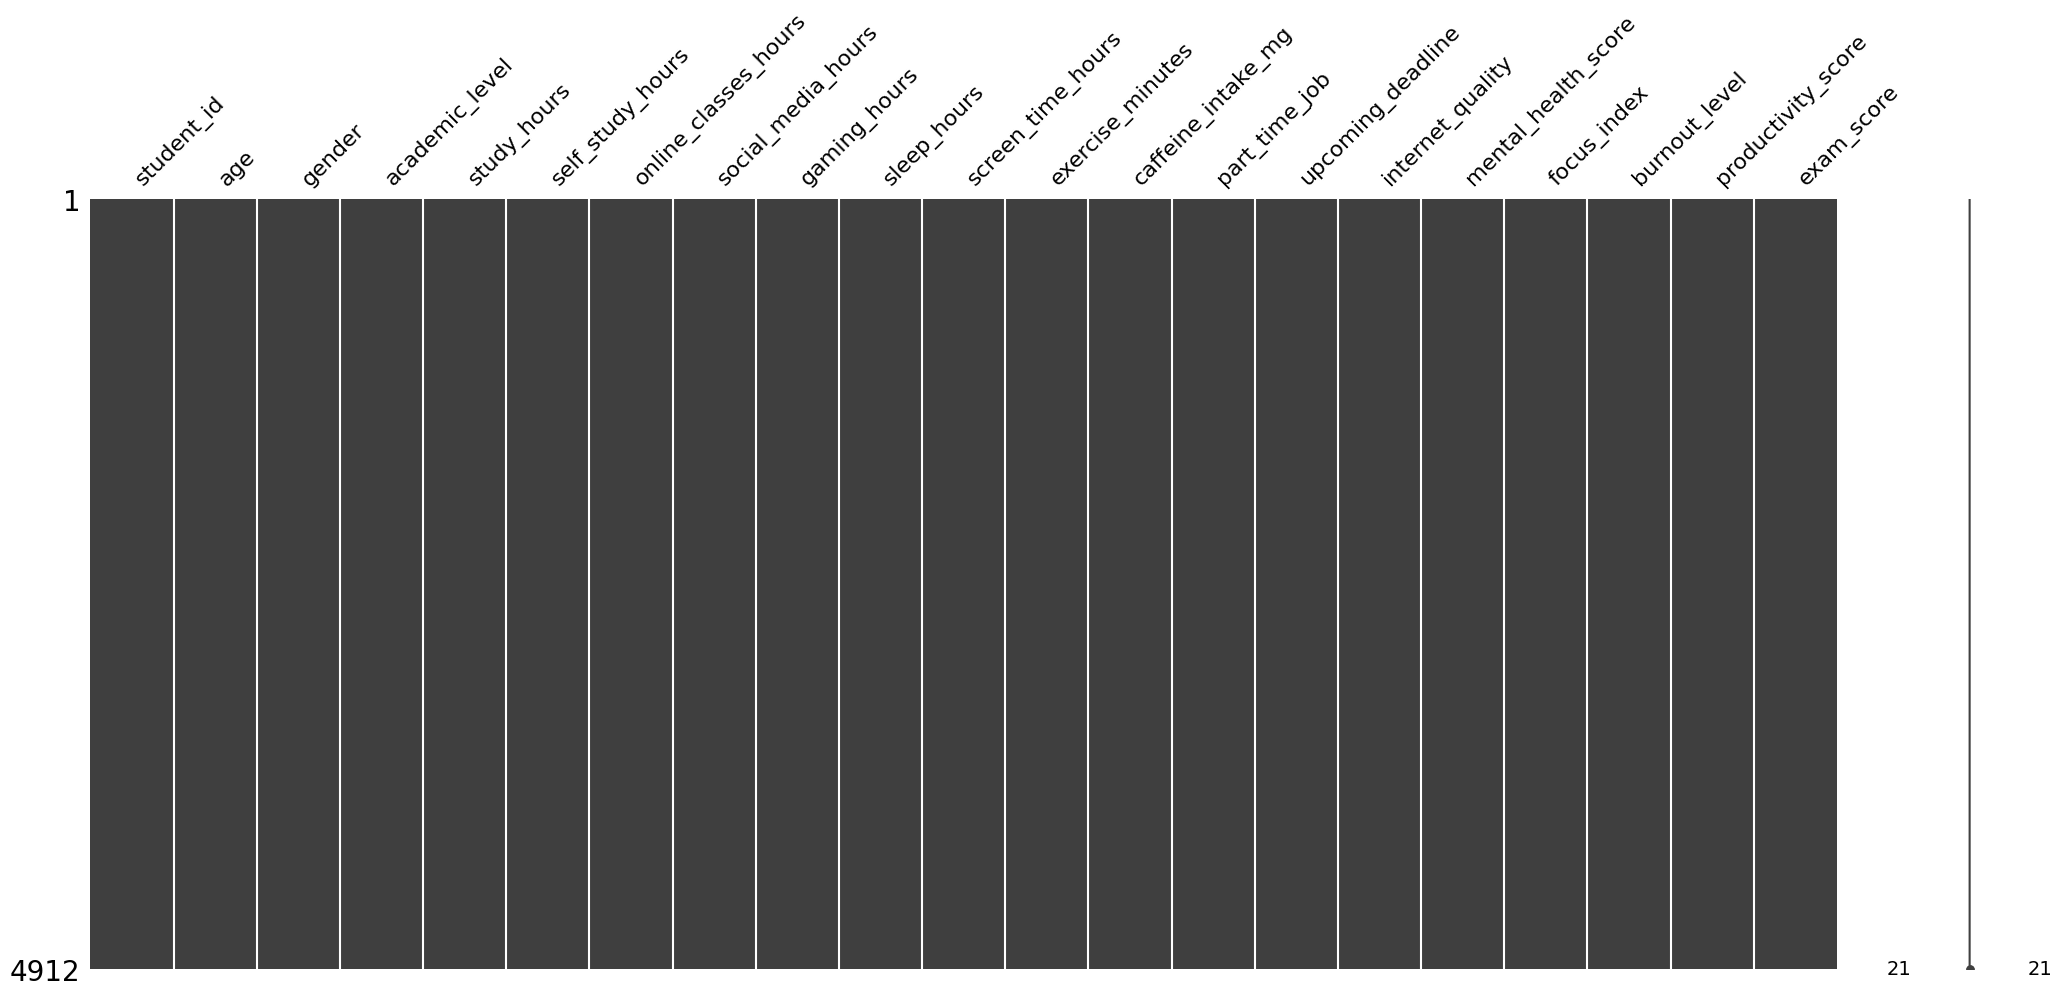

In [6]:
msno.matrix(df)

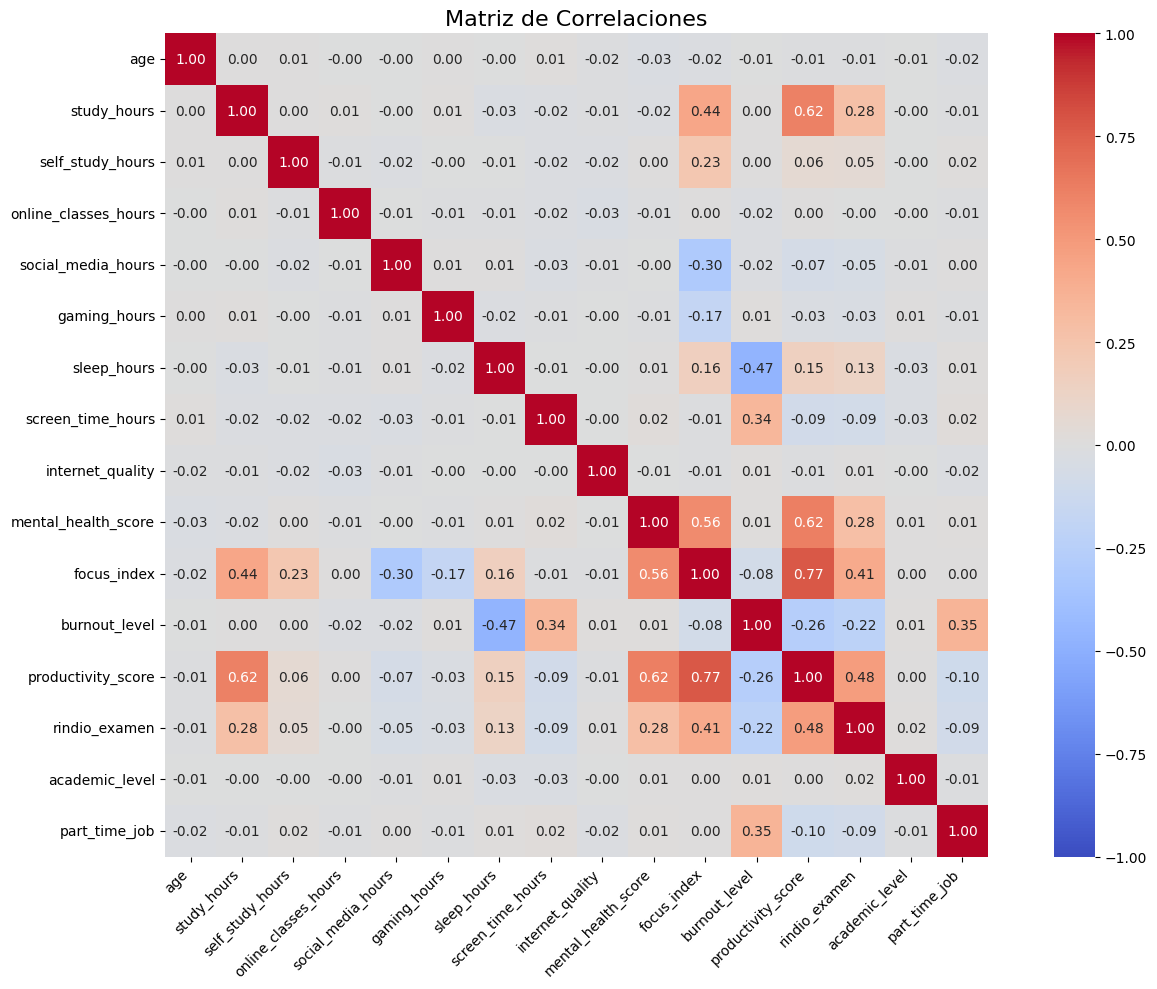

In [7]:
df_modelo = df.dropna(subset=['exam_score']).copy()
df_modelo['rindio_examen'] = (df_modelo['exam_score'] > 1.0).astype(int)
cols_for_corr = [
    'age', 'study_hours', 'self_study_hours', 'online_classes_hours',
    'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours',
    #'exercise_minutes', 'caffeine_intake_mg', 'upcoming_deadline',
    'internet_quality', 'mental_health_score', 'focus_index', 'burnout_level',
    'productivity_score', 'rindio_examen',
    'academic_level', 'part_time_job'
]

corr_matrix = df_modelo[cols_for_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            vmin=-1, vmax=1, center=0, square=True)
plt.title("Matriz de Correlaciones", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('matriz_correlacion.png') # Guarda la imagen

2. Ejecute un modelo de probabilidad lineal (*MCO*) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [8]:
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,20,Male,2,5.37,2.09,1.85,3.66,2.32,7.73,...,54.0,475.0,0,0.0,3.0,3.0,19.01,31.77,42.59,25.08
1,2,16,Female,1,5.85,5.04,1.87,3.60,2.79,6.11,...,63.0,362.0,0,0.0,3.0,10.0,42.10,45.89,67.15,37.83
2,3,18,Female,2,5.69,2.27,0.00,2.93,3.94,7.11,...,28.0,200.0,0,0.0,2.0,5.0,21.93,37.07,37.68,18.66
3,4,24,Male,2,2.32,1.06,2.30,4.34,2.37,8.54,...,55.0,233.0,0,1.0,1.0,3.0,13.47,43.63,12.83,1.00
4,5,24,Female,3,3.87,2.63,2.54,3.71,1.30,7.69,...,60.0,159.0,0,1.0,1.0,2.0,19.95,56.62,18.53,7.78


Ya con las variables limpiadas

In [9]:
df_modelo = df.dropna(subset=['exam_score']).copy()
df_modelo['rindio_examen'] = (df_modelo['exam_score'] > 1.0).astype(int)
# Creamos un dataset limpio solo para el modelo (sin nulos en estas variables)


# Definimos variables independientes (X) y dependiente (Y)
formula = """
    rindio_examen ~ 
        C(academic_level) + 
        self_study_hours + 
        mental_health_score + 
        C(internet_quality) +
        burnout_level * C(part_time_job) + 
        focus_index 
"""

# Añadir la constante (intercepto) para el modelo MCO

# Ejecutar el modelo de Mínimos Cuadrados Ordinarios (OLS / MCO)
modelo_lpm = smf.ols(formula=formula, data=df_modelo).fit(cov_type='HC3')

# Imprimir los resultados estadísticos
print(modelo_lpm.summary())

                            OLS Regression Results                            
Dep. Variable:          rindio_examen   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     66.26
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          3.49e-127
Time:                        03:22:01   Log-Likelihood:                -218.94
No. Observations:                4912   AIC:                             459.9
Df Residuals:                    4901   BIC:                             531.4
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

3. Ejecute un modelo *probit* para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [10]:
modelo_probit = smf.probit(formula=formula, data=df_modelo).fit()
print(modelo_probit.summary())
mfx = modelo_probit.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.168357
         Iterations 8
                          Probit Regression Results                           
Dep. Variable:          rindio_examen   No. Observations:                 4912
Model:                         Probit   Df Residuals:                     4901
Method:                           MLE   Df Model:                           10
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4408
Time:                        03:22:01   Log-Likelihood:                -826.97
converged:                       True   LL-Null:                       -1478.9
Covariance Type:            nonrobust   LLR p-value:                5.466e-274
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               0.8960      0.264 

Analizamos los efectos marginales, y vemos que en los coeficientes significativos, en la variable mental_health_score, por cada punto que aumenta esta variable, la probabilidad de que el alumno se presente al examen aumenta en 1.19 puntos porcentuales. Luego en la variable focus_index, por cada punto extra en el nivel de concentracion, la probabilidad de rendir el examen aumenta en 1.02 puntos porcentuales, por ultimo los estudiantes que pertenecen al nivel academico 2, en el cual seria los estudiantes de pregrado, tienen una probabilidad de 2.7 puntos porcentuales mayor de rendir el examen en comparacion con los estudiantes de categoria de nivel academico 1 los cuales serian los de High School. 
Las variables que disminuyes las probabilidades de rendir el examen serian que por cada hora adicional de autoestudio, la probabilidad cae en un 1.12 puntos porcentuales, al igual que burnout_level, la probabilidad cae en un 0.45 puntos porcentuales

4. Ejecute un modelo *logit*  para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [11]:
modelo_logit = smf.logit(formula=formula, data=df_modelo).fit()
print(modelo_logit.summary())
mfx = modelo_logit.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.168392
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          rindio_examen   No. Observations:                 4912
Model:                          Logit   Df Residuals:                     4901
Method:                           MLE   Df Model:                           10
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4407
Time:                        03:22:01   Log-Likelihood:                -827.14
converged:                       True   LL-Null:                       -1478.9
Covariance Type:            nonrobust   LLR p-value:                6.495e-274
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               1.5843      0.499 

Al igual que antes, las variables que impactan positivamente la probabilidad son los estudiantes que pertenecen a pregrado, la variable mental_health_score y focus_index los cuales impactan en un 2.87, 1.20 y 1.03 puntos porcentuales respectivamente. Y las variables que impactan negativamente son self_study_hours y burnout_level con 1.11 y 0.46 puntos porcentuales respectivamente. 

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

| Variable Independiente | MCO (OLS) | Probit (Efectos Marginales) | Logit (Efectos Marginales) |
| :--- | :--- | :--- | :--- |
| **Intercept** | 0.7212*** (0.022) | -- | -- |
| **C(academic_level)[T.2]** | 0.0320*** (0.009) | 0.0270*** (0.008) | 0.0287*** (0.008) |
| **C(academic_level)[T.3]** | 0.0103 (0.009) | 0.0097 (0.008) | 0.0115 (0.008) |
| **C(internet_quality)[T.2.0]** | 0.0059 (0.009) | -0.0007 (0.008) | -0.0005 (0.008) |
| **C(internet_quality)[T.3.0]** | 0.0096 (0.009) | 0.0015 (0.008) | 0.0016 (0.008) |
| **C(part_time_job)[T.1]** | 0.0296 (0.026) | -0.0520 (0.029) | -0.0553 (0.030) |
| **self_study_hours** | -0.0083* (0.003) | -0.0112*** (0.003) | -0.0111*** (0.003) |
| **mental_health_score** | 0.0088*** (0.001) | 0.0119*** (0.002) | 0.0120*** (0.002) |
| **burnout_level** | -0.0033*** (0.000) | -0.0045*** (0.000) | -0.0046*** (0.000) |
| **burnout_level:C(part_time_job)[T.1]** | -0.0010 (0.001) | 0.0009 (0.001) | 0.0009 (0.001) |
| **focus_index** | 0.0103*** (0.001) | 0.0102*** (0.000) | 0.0103*** (0.000) |

*Nota 1: Los valores de Probit y Logit corresponden a efectos marginales promedio (dy/dx).*
*Nota 2: Errores estándar en paréntesis. Significancia: \* p < 0.05, \*\* p < 0.01, \*\*\* p < 0.001.*

| Modelo | Tipo de Medida de Ajuste | Valor del R² 
| :--- | :--- | :--- | 
| **MCO (OLS)** | R-cuadrado estándar | 0.2140 
| **Probit** | Pseudo R-cuadrado (McFadden) | 0.4408 
| **Logit** | Pseudo R-cuadrado (McFadden) | 0.4407 

Estas diferencias se explican por la matematica detras del modelo, en OLS los coeficientes se interpretan directamente como cambios en la probabilidad base, en Logit los coeficientes estan en unidades de Log-Odds y en Probit los coeficientes estan en la escala de desviaciones estandar de una distribucion normal.
Comparando los valores R², OLS muestra un R² de 0,214 mientras que Logit y Probit se acercan a 0.44, pero como el R² de McFadden mide la mejora del modelo respecto a uno sin variables, el OLS mide la varianza explicada.
El modelo mas adecuado es el Logit o Probit, por sobre el OLS. Porque la variable dependiente es binaria, en OLS asume una linea recta al infinito, por lo que si un estudiante tiene puntajes altisimos de salud mental, OLS podria predecir que tiene un 120% de probabilidad de rendir el examen lo cual es imposible.
Nuestras variables robustas son focus_ndex ya que en los tres modelos fue positivas y fueron significativos, al igual que mental_health_score y C(academic_level)[T.2]. Y las que fueron negativas fue burnout_level y self_study_hours

6. Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [18]:
df_rindieron = df[df['exam_score'] > 1.0].copy()
df_rindieron['exam_score_int'] = df_rindieron['exam_score']#.round().astype(int)

formula_poisson = """
    exam_score_int ~ 
        C(academic_level) + 
        self_study_hours + 
        mental_health_score + 
        C(internet_quality) +
        burnout_level * C(part_time_job) + 
        focus_index 
"""
modelo_poisson = smf.poisson(formula=formula_poisson, data=df_rindieron).fit()
print(modelo_poisson.summary())
efectos_marginales_poisson = modelo_poisson.get_margeff()
print(efectos_marginales_poisson.summary())
#irr = np.exp(modelo_poisson.params)
#print(irr)

Optimization terminated successfully.
         Current function value: 3.620373
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 4473
Model:                        Poisson   Df Residuals:                     4462
Method:                           MLE   Df Model:                           10
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3534
Time:                        03:52:19   Log-Likelihood:                -16194.
converged:                       True   LL-Null:                       -25045.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               2.3117      0.021 

Las variables que suman puntos a la nota son mental_health_score y focus_index es que aumentan 0.81 y 0.73 puntos respectivamente, y las variables que restan puntos a la nota son self_study_hours y burnout_level son 0.64 y 0.28 puntos menos en el examen respectivamente.

7. Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

In [ ]:
import statsmodels.api as sm


mu_pred = modelo_poisson.predict()
y_real = df_rindieron['exam_score_int']

aux_y = ((y_real - mu_pred)**2) - y_real

aux_x = mu_pred**2


modelo_auxiliar = sm.OLS(aux_y, aux_x).fit()


alpha_estimado = modelo_auxiliar.params.iloc[0]
p_valor_alpha = modelo_auxiliar.pvalues.iloc[0]


print(f"Valor estimado de Alpha: {alpha_estimado:.4f}")
print(f"P-valor de Alpha: {p_valor_alpha:.4f}")

if p_valor_alpha < 0.05:
    print("\nConclusión: El P-valor es menor a 0.05. Alpha es significativamente mayor a 0.")
    print("Hay sobredispersión en los datos, por lo que el modelo de Poisson no es adecuado. Se recomienda usar el modelo de Binomial Negativa.")
else:
    print("\nConclusión: Alpha no es significativo. Poisson es suficiente.")

Valor estimado de Alpha: 0.0323
P-valor de Alpha: 0.0000

Conclusión: El P-valor es menor a 0.05. Alpha es significativamente mayor a 0.
¡Existe sobredispersión! Debes usar el modelo Binomial Negativa.


8. Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [19]:
modelo_bn = smf.negativebinomial(formula=formula_poisson, data=df_rindieron).fit(disp=0)
print(modelo_bn.summary())
efectos_marginales_bn = modelo_bn.get_margeff()
print(efectos_marginales_bn.summary())


                     NegativeBinomial Regression Results                      
Dep. Variable:         exam_score_int   No. Observations:                 4473
Model:               NegativeBinomial   Df Residuals:                     4462
Method:                           MLE   Df Model:                           10
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1169
Time:                        03:53:05   Log-Likelihood:                -15079.
converged:                       True   LL-Null:                       -17074.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               2.2562      0.035     64.407      0.000       2.188       2.325
C(academic_level)[T.2]                 -0.0035      0.01

C:\Users\MatiasPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\MatiasPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Tenemos las mismas conclusiones que en el resto de modelos en donde las variables mental_health_score y focus_index en donde impactan 0.84 y 0.80 puntos mas adicionales en la nota y las variables que impactan negativamente son self_study_hours y burnout_level con 0.66 y 0.30 puntos en la nota respectivamente.

9. Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

| Variable Independiente | Poisson (dy/dx) | Binomial Negativa (dy/dx) |
| :--- | :--- | :--- |
| **C(academic_level)[T.2]** | -0.1340 (0.166) | -0.0730 (0.281) |
| **C(academic_level)[T.3]** | -0.2570 (0.167) | -0.2788 (0.283) |
| **C(internet_quality)[T.2.0]** | -0.0808 (0.166) | -0.0302 (0.281) |
| **C(internet_quality)[T.3.0]** | 0.1399 (0.168) | 0.1747 (0.283) |
| **C(part_time_job)[T.1]** | 0.2978 (0.474) | 0.4341 (0.830) |
| **self_study_hours** | -0.6368*** (0.061) | -0.6593*** (0.103) |
| **mental_health_score** | 0.8120*** (0.030) | 0.8376*** (0.050) |
| **burnout_level** | -0.2801*** (0.007) | -0.3026*** (0.013) |
| **burnout_level:C(part_time_job)[T.1]** | -0.0185 (0.011) | -0.0209 (0.018) |
| **focus_index** | 0.7343*** (0.009) | 0.7980*** (0.017) |

*Nota 1: Los valores representan el cambio en puntos reales de la nota (escala 1-64).*
*Nota 2: Errores estándar en paréntesis. Significancia: \*\*\* p < 0.001.*
*Nota 3: Parámetro de sobredispersión estimado $\alpha = 0.0323$.*

Las diferencias entre Poisson y Binomial Negativa es que Poisson asume que no hay caos extra en los datos, es decir que la varianza es igual a la media, como ignoramos ese alpha, el modelo tiende a subestimar los errores estandar, lo que puede hacer que algunas variables parezcan mas importantes de lo que realmente son. En cambio en la binomial negativa, al ver que alpha es mayor que 0, el modelo aumenta los errores lo que causa que los efectos marginales sean ligeramente mas altos en algunos casos ya que la binomial negativa entiende la relacion entre las variables. 
En mi opinion el mas adecuado seria la binomial negativa ya que el alpha estimado demuestra que existe sobredispersion y tambien es significativo.
Las variables que resultaron ser robustas mental_health_score, focus_index, self_study_hours y burnout_level en donde se comportaron de manera estable en ambos modelos